## Results Analysis

The results follow this order: time and feasibility; presets; execution type; gradient method; randomness; scaling; and implementation/packing validation.

Unless stated otherwise, quality figures use completed 1000-epoch simulator runs. CPU/GPU copies of the same scientific run are collapsed for quality analysis, while device remains explicit in timing. Comparison figures show evaluation only, with faint run traces and median/IQR shadows showing variation across seeds. The sole exception is the preset learning-dynamics comparison in Section 2.1, which retains the joined blue generator-loss, red discriminator-loss, and orange evaluation layout.


In [4]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
qgan_dir = next(
    (
        candidate
        for root in (cwd, *cwd.parents)
        for candidate in (root, root / "qgan")
        if (candidate / "src" / "qgan_v2").is_dir()
    ),
    None,
)
if qgan_dir is None:
    raise RuntimeError("Could not find the qgan project directory.")

src_path = qgan_dir / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
repo_root = qgan_dir.parent
print({"qgan_dir": qgan_dir, "repo_root": repo_root})

{'qgan_dir': PosixPath('/home/benat/Qiskit-IBM/qgan'), 'repo_root': PosixPath('/home/benat/Qiskit-IBM')}


In [5]:
from qgan_v2.analysis import ResultsAnalysis

### Analysis setup and figure export

Set `EXPORT_FIGURES = True` to save PDF and 300-dpi PNG versions under `qgan/figures/results_analysis`. Each subsection keeps its scientific filters and comparison choices visible in the notebook; reusable loading and plotting mechanics live in `qgan_v2.analysis`. KL divergence (`base`) and image-gradient scores (`ang`/`amp`) are faceted rather than pooled because their scales are not comparable.


In [6]:
EXPORT_FIGURES = False
GPU_MODEL_LABEL = "RTX6000"  # Change if another GPU timing battery is loaded.
PRESET_ORDER = ("base", "ang", "amp")
GRADIENT_ORDER = ("PSR", "REG", "SPSA")

analysis = ResultsAnalysis.load(
    qgan_dir,
    export_figures=EXPORT_FIGURES,
    gpu_model_label=GPU_MODEL_LABEL,
)
analysis.results.summary()

{'raw_convergence/case-study_configs': 717,
 'completed_deduplicated_simulator_runs': 374,
 'completed_five_epoch_timing_runs': 224,
 'usable_real_hardware_runs': 3,
 'usable_implementation_validation_runs': 8,
 'evaluation_families': {'gradient': 223, 'kl': 151}}

### 1. Time, Cost, and Feasibility

Timing comes first so the reader knows which experiments were computationally practical before interpreting model quality.


#### 1.1 Time analysis

These panels use completed five-epoch timing batteries. Median time per epoch is reported because it is less sensitive to a slow initialization epoch. The factors are preset, execution type, gradient method, and `rand0`/`rand1`.

The timing environments are the one-CPU battery (`CPU/1`), the explicit four-CPU battery (`CPU/4`), and the configured GPU battery. Every series is plotted on the exact categorical tick—there is no horizontal series offset.


timing environments: ['CPU/1', 'CPU/4', 'GPU (RTX6000)']


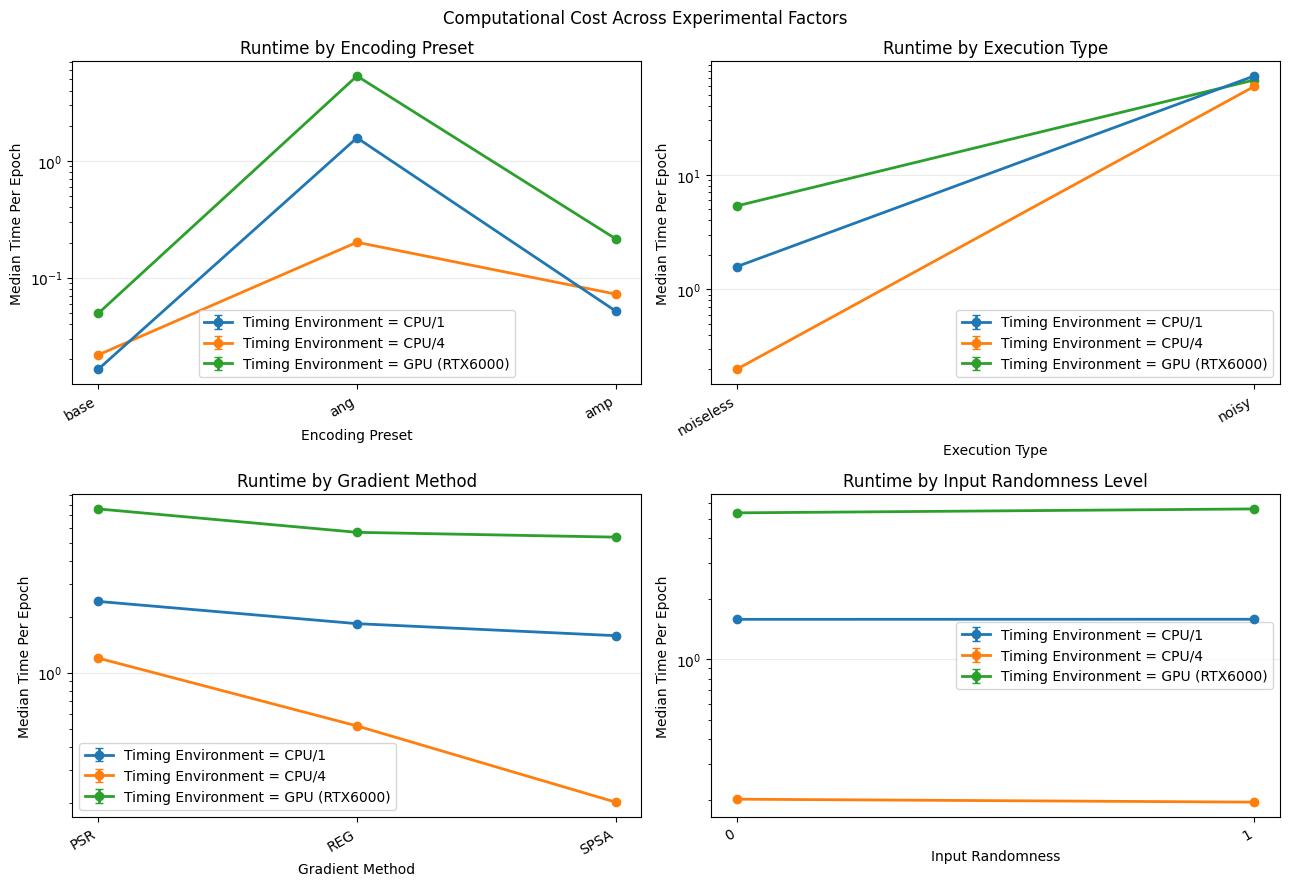

In [7]:
TIMING_BASELINE = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
}
primary_timing = analysis.timing(
    baseline_filters=TIMING_BASELINE,
    factor_levels={"randomness": (0, 1)},
)

#### 1.2 Experimental limitations and feasibility

This subsection records the known resource boundary for each omitted or unfinished experiment class. It deliberately excludes `fake_real`, which is an implementation-validation mode rather than a feasibility result. The completion matrix expands one selected convergence battery (CPU or GPU, never both) and the CPU, GPU, and real-hardware timing batteries. For every requested config, the generated run directory is checked for `training_data.pth`; a run is complete only when its recorded epochs reach the battery config's `training.max_iterations`. The adjacent bars partition the matrix's incomplete requests by limitation, so their per-qubit totals match the incomplete counts in the matrix.

The categories distinguish time cost, unavailable real-hardware execution time, statevector transpilation limits, and CPU memory limits. They should be interpreted as experimental design constraints, not model-quality outcomes.


convergence battery: train_conv_gpu.yaml
timing batteries: ['train_times_cpu.yaml', 'train_times_gpu.yaml', 'train_times_rh.yaml']
{'n_qubits': 4, 'experiment': 'noisy PSR', 'limitation': 'time-expensive', 'detail': 'Parameter-shift noisy convergence did not finish.', 'battery_reference': 'train_conv_cpu.yaml / train_conv_gpu.yaml'}
{'n_qubits': 4, 'experiment': 'real hardware', 'limitation': 'execution time unavailable', 'detail': 'Only runs with completed real-hardware timing checkpoints are available.', 'battery_reference': 'train_times_rh.yaml'}
{'n_qubits': 8, 'experiment': 'noisy PSR', 'limitation': 'time-expensive', 'detail': 'Parameter-shift noisy convergence did not finish.', 'battery_reference': 'train_conv_cpu.yaml / train_conv_gpu.yaml'}
{'n_qubits': 16, 'experiment': 'amplitude preset', 'limitation': 'not transpilable', 'detail': 'The statevector preparation circuit was too large/deep to transpile.', 'battery_reference': 'train_conv_cpu.yaml / train_conv_gpu.yaml'}
{'n_qub

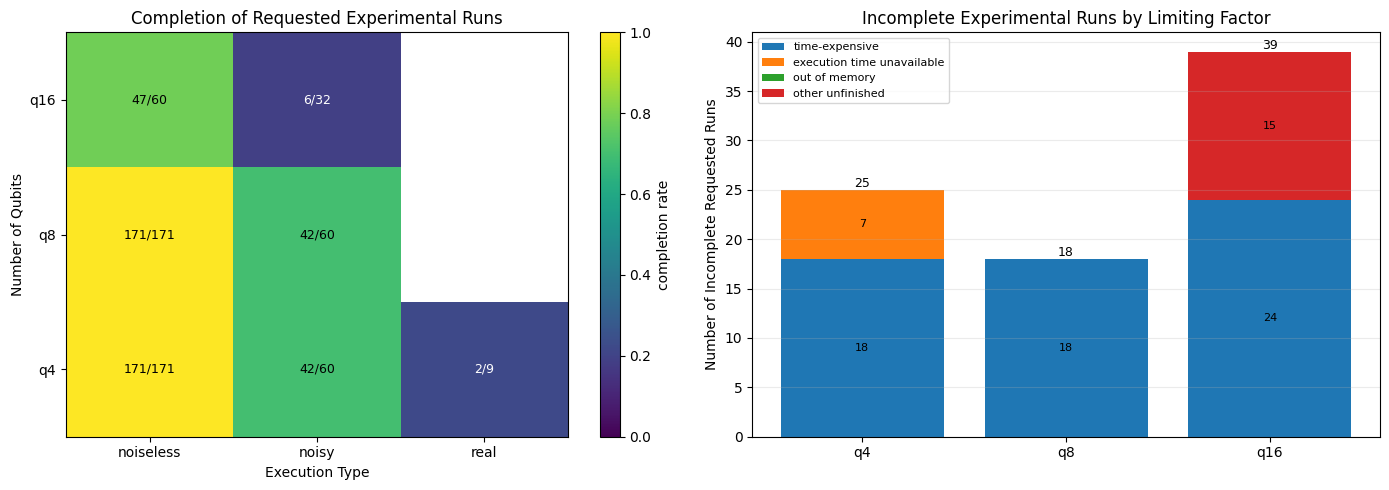

In [8]:
CONVERGENCE_BATTERY = qgan_dir / "configs/batteries/train/train_conv_gpu.yaml"
TIMING_BATTERIES = (
    qgan_dir / "configs/batteries/train/train_times_cpu.yaml",
    qgan_dir / "configs/batteries/train/train_times_gpu.yaml",
    qgan_dir / "configs/batteries/train/train_times_rh.yaml",
)

feasibility_results = analysis.feasibility(
    convergence_battery=CONVERGENCE_BATTERY,
    timing_batteries=TIMING_BATTERIES,
)

### 2. Presets

This section establishes how the three data/encoding presets learn and then links the quantitative curves to generated outputs.


#### 2.1 Learning dynamics and best results

The comparison fixes noiseless PSR, `q4`, `rand0`, and seeds 0–2. Each preset has its own column because `base` minimizes KL divergence over a target probability distribution, while `ang` and `amp` use an image-gradient score.

Each preset column retains adversarial losses above evaluation: faint traces identify individual seed runs and solid lines with shadows give the median and IQR. The summary panels show best evaluation and the epoch at which it occurs; point color identifies the seed. This is the only subsection whose learning-dynamics graph includes generator and discriminator losses.


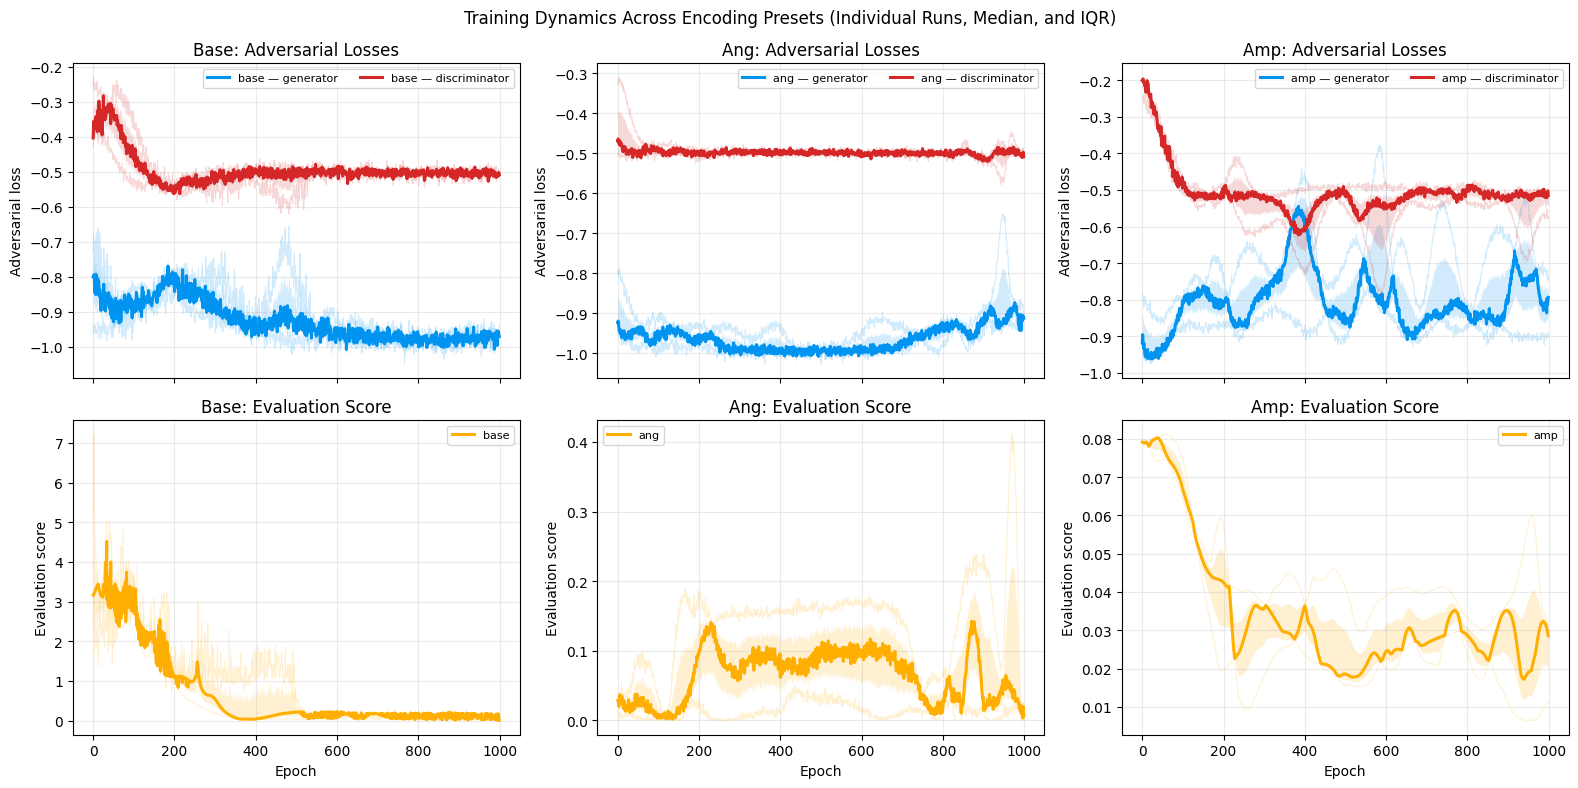

In [9]:
PRESET_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "PSR",
    "n_qubits": 4,
    "randomness": 0,
}
preset_runs = analysis.preset_learning_dynamics(
    filters=PRESET_FOCUS,
    presets=PRESET_ORDER,
)

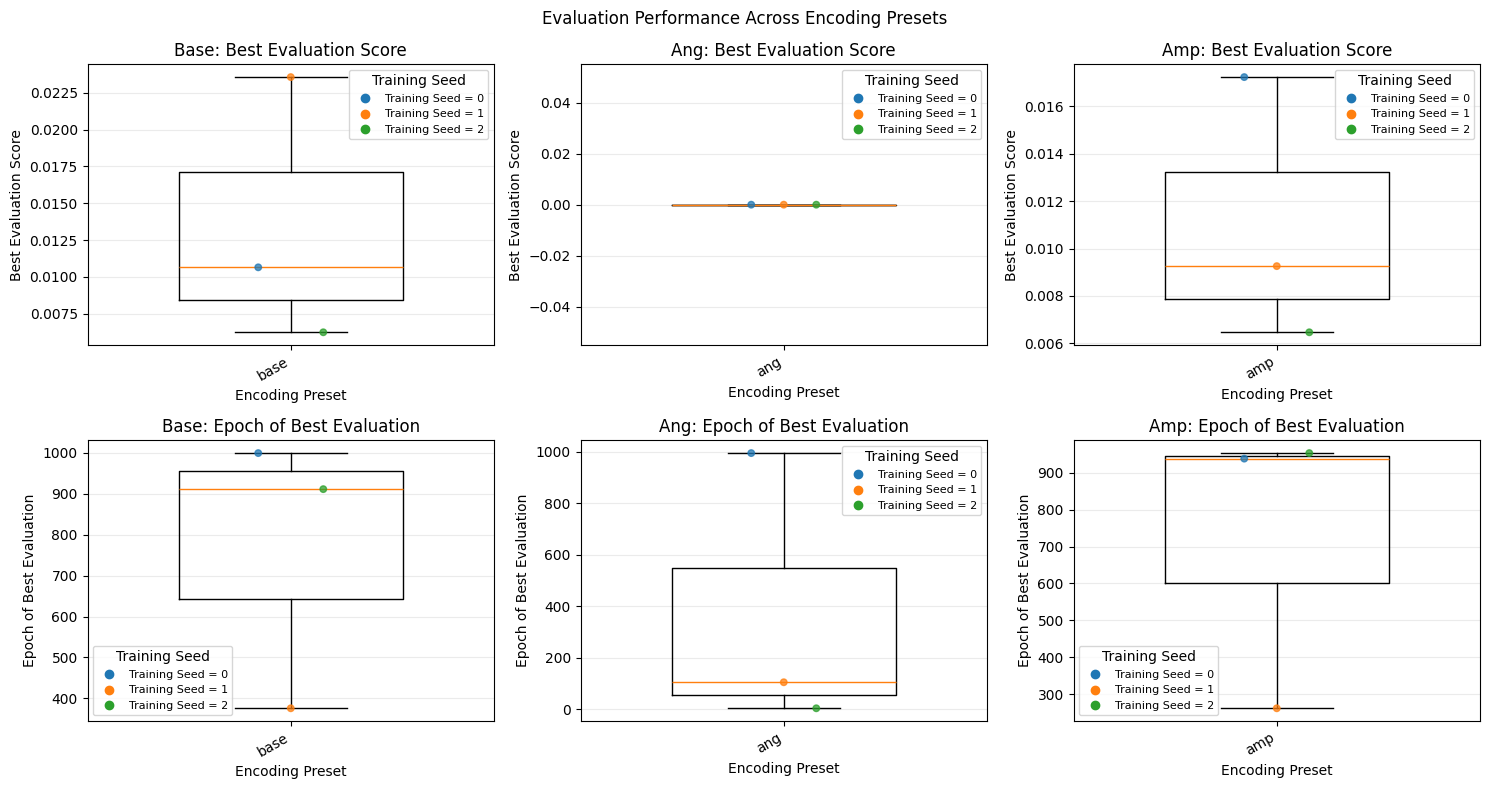

{'eval_method': 'gradient', 'preset': 'amp', 'completed_runs': 3, 'seeds': (0, 1, 2), 'median_best_eval': 0.009257595755188766, 'q25_best_eval': 0.007863034817550045, 'q75_best_eval': 0.013242806418764902, 'median_epoch_of_best_eval': 938.0}
{'eval_method': 'gradient', 'preset': 'ang', 'completed_runs': 3, 'seeds': (0, 1, 2), 'median_best_eval': 0.0, 'q25_best_eval': -0.0, 'q75_best_eval': -0.0, 'median_epoch_of_best_eval': 105.0}
{'eval_method': 'kl', 'preset': 'base', 'completed_runs': 3, 'seeds': (0, 1, 2), 'median_best_eval': 0.010651926471313883, 'q25_best_eval': 0.008447673538135969, 'q75_best_eval': 0.01710671319668662, 'median_epoch_of_best_eval': 911.0}


In [10]:
preset_performance = analysis.preset_best_results(
    preset_runs,
    presets=PRESET_ORDER,
)

#### 2.2 Initial, last, best, and target outputs

The gradient method, randomness level, and training seed for the displayed noiseless `q4` runs can be selected explicitly below. The defaults match subsection 2.1: PSR, `rand0`, and seed 0. The initial, final-checkpoint, best-checkpoint, and target outputs are rendered together in one `1 × 4` row for each preset, making the full qualitative change and any regression after the optimum directly visible. `QUALITATIVE_RANDOM_SEED` in the following cell controls output sampling and is separate from the selected training seed.


In [11]:
OUTPUT_GRADIENT_METHOD = "PSR"
OUTPUT_RANDOMNESS = 0
OUTPUT_SEED = 1

OUTPUT_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "n_qubits": 4,
    "gradient_method": OUTPUT_GRADIENT_METHOD,
    "randomness": OUTPUT_RANDOMNESS,
    "seed": OUTPUT_SEED,
}
preset_output_manifest = analysis.select_preset_outputs(
    filters=OUTPUT_FOCUS,
    presets=PRESET_ORDER,
    gradient_priority=GRADIENT_ORDER,
)

{'preset': 'base', 'run_id': 'base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1', 'gradient_method': 'PSR', 'randomness': 0, 'seed': 1, 'evaluation_metric': 'kl', 'best_eval': 0.02356149992205936, 'epoch_of_best_eval': 376, 'last_eval': 0.17359444889233214, 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1/config.yaml'}
{'preset': 'ang', 'run_id': 'ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1', 'gradient_method': 'PSR', 'randomness': 0, 'seed': 1, 'evaluation_metric': 'gradient', 'best_eval': -0.0, 'epoch_of_best_eval': 105, 'last_eval': 0.023232165724039078, 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1/config.yaml'}
{'preset': 'amp', 'run_id': 'amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1', 'gradient_method': 'PSR', 'randomness': 0, 'seed': 1, 'evaluation_metric': 'gradient', 'best_eval': 0.009257595755188766, 'epoch_of_best_eval': 262, 'last_eval': 0.03154456

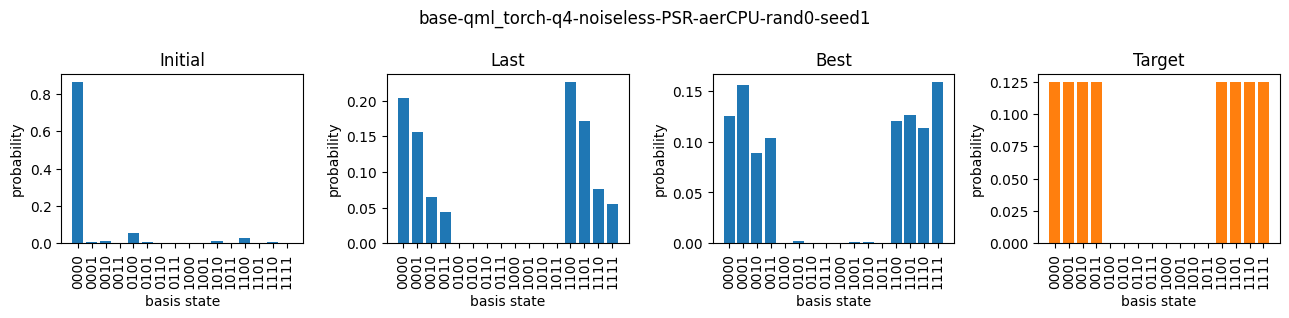

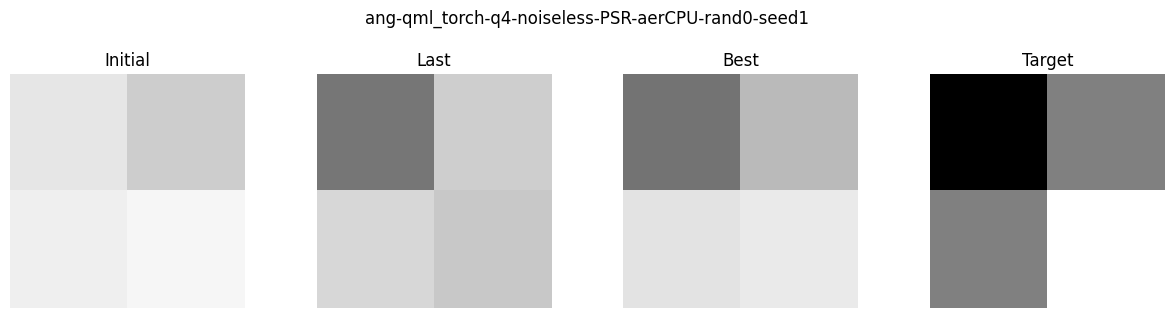

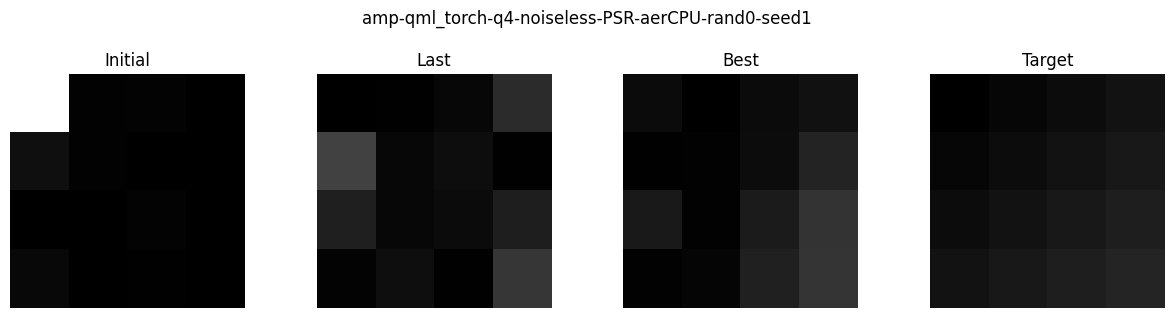

{'preset': 'base', 'run_id': 'base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1', 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1/config.yaml', 'execution_type': 'noiseless', 'parameter_sets': ('initial', 'last', 'best'), 'random_seed': 0, 'evaluations': {'initial': {'score': nan, 'epoch': None}, 'last': {'score': 0.17359444889233214, 'epoch': 999}, 'best': {'score': 0.02356149992205936, 'epoch': 376}}}
{'preset': 'ang', 'run_id': 'ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1', 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1/config.yaml', 'execution_type': 'noiseless', 'parameter_sets': ('initial', 'last', 'best'), 'random_seed': 0, 'evaluations': {'initial': {'score': nan, 'epoch': None}, 'last': {'score': 0.023232165724039078, 'epoch': 999}, 'best': {'score': -0.0, 'epoch': 105}}}
{'preset': 'amp', 'run_id': 'amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1', 'con

In [12]:
RENDER_PRESET_OUTPUTS = True
QUALITATIVE_RANDOM_SEED = 0

if RENDER_PRESET_OUTPUTS:
    rendered_output_manifest = analysis.render_preset_outputs(
        random_seed=QUALITATIVE_RANDOM_SEED
    )
else:
    print("Set RENDER_PRESET_OUTPUTS = True to create the four-panel output figures.")

### 3. Execution-Type Comparison

Simulation provides the replicated comparison; the much smaller real-hardware sample is separated so its evidential limits remain explicit.


#### 3.1 Noiseless versus noisy simulation

This comparison uses matched `q4`, SPSA, `rand0`, seeds 0–2. Each preset remains in its own metric column. Learning curves show evaluation only; summaries retain best evaluation and best epoch.


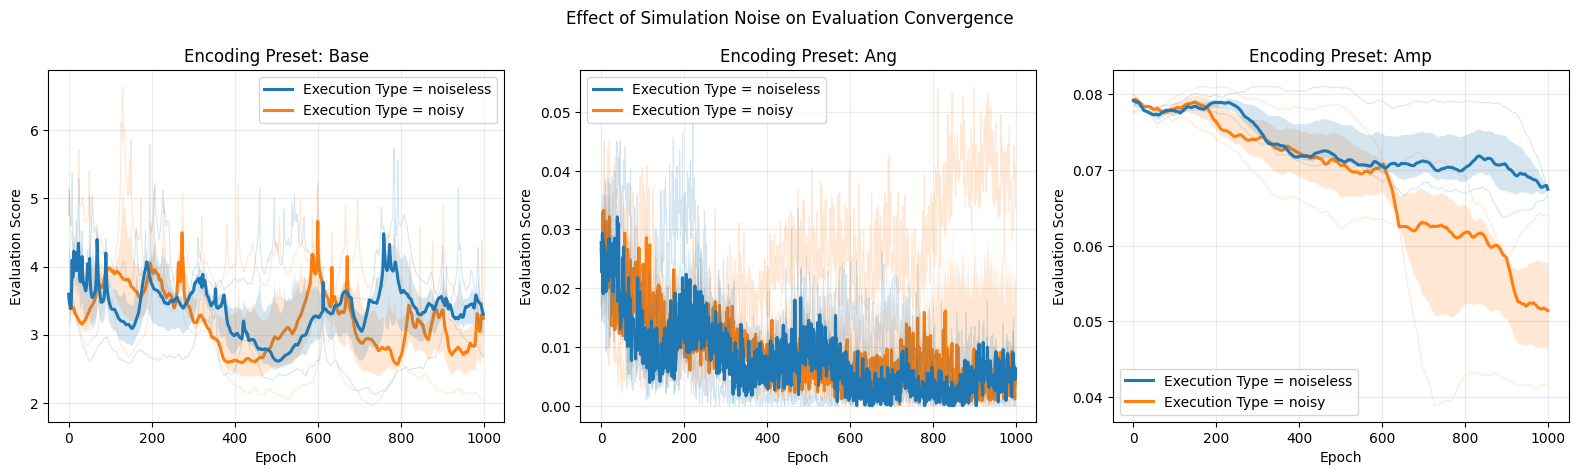

In [13]:
SIMULATION_EXECUTION_FOCUS = {
    "implementation": "qml_torch",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
    "execution_type": ("noiseless", "noisy"),
}
simulation_execution_runs = analysis.simulation_execution_dynamics(
    filters=SIMULATION_EXECUTION_FOCUS,
    presets=PRESET_ORDER,
)

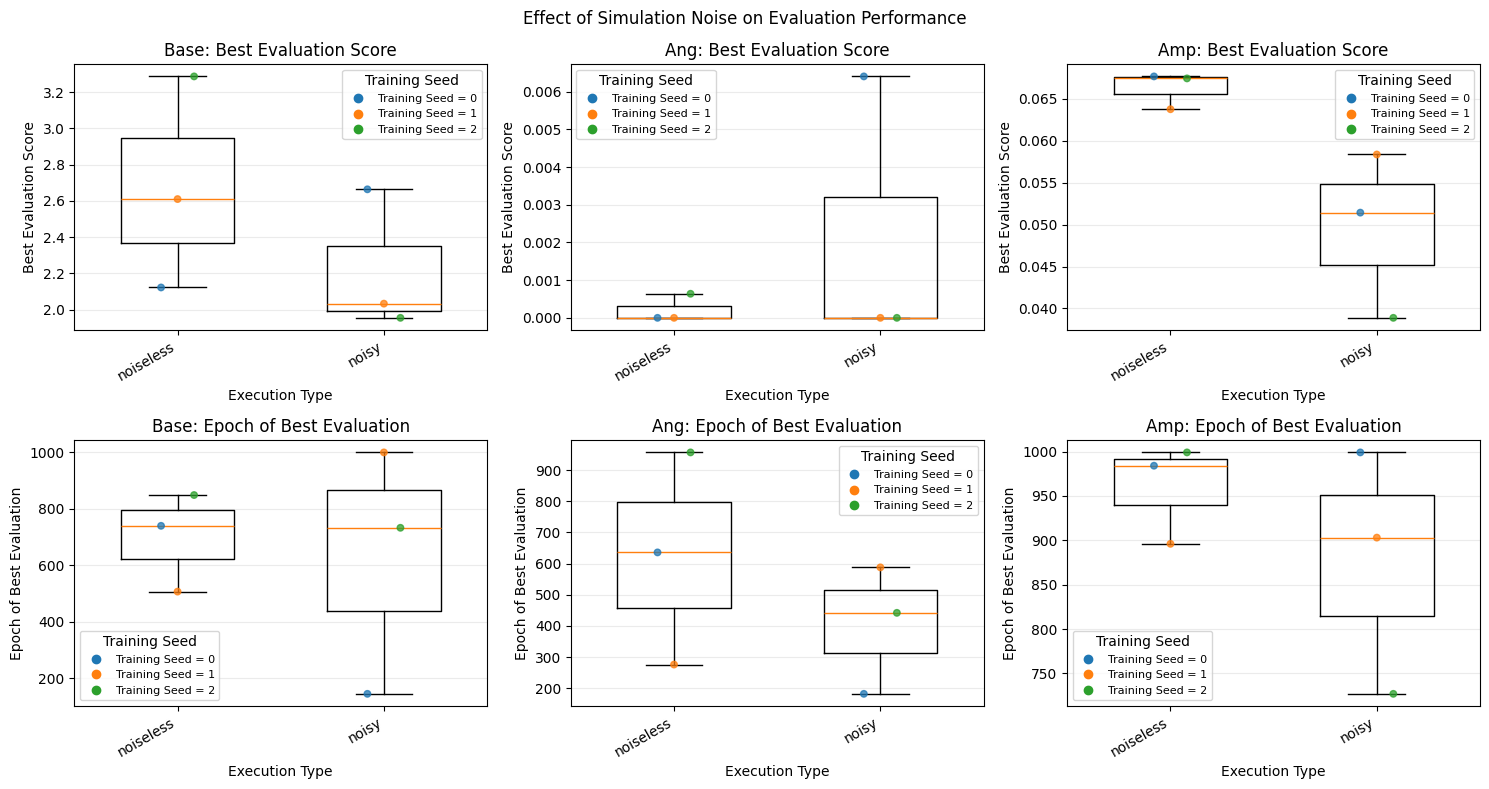

[RunResult(path=PosixPath('/home/benat/Qiskit-IBM/qgan/data/train/amp-qml_torch-q4-noiseless-SPSA-aerCPU-rand0-seed0'), config={'implementation': {'name': 'qml_torch', 'discriminator_packing': 'separate'}, 'run': {'id': 'amp-qml_torch-q4-noiseless-SPSA-aerCPU-rand0-seed0', 'label': None, 'data_path': 'qgan/data/train', 'seed': 0, 'device': 'CPU'}, 'experiment': {'implementation': 'amp', 'execution_type': 'noiseless', 'n_qubits': 4, 'gradient_method': 'SPSA'}, 'training': {'max_iterations': 1000, 'gen_iterations': 1, 'disc_iterations': 1, 'init_scale': 0.1, 'learning_rate': 0.005, 'print_every': 10, 'checkpoint_every': 10}, 'dataset': {'id': 'generated_gradients-total_pixels16', 'reset': False, 'type': 'classical', 'source': 'generated_gradients', 'parameters': {'total_pixels': 16}}, 'circuits': {'reset': False, 'generator': 'real_amplitudes', 'discriminator': 'efficient_su2'}, 'backend': {'reset': False, 'save_backend_file': False, 'precision': 0.015625, 'transpilation': {'optimization

In [14]:
analysis.simulation_execution_best_results(
    simulation_execution_runs,
    presets=PRESET_ORDER,
)

#### 3.2 Noiseless, noisy, and real hardware

The two available real-QPU runs are compared against matching simulator runs truncated to the same observed epoch budget. This is behavioral evidence for those runs, not a replicated estimate of hardware performance.


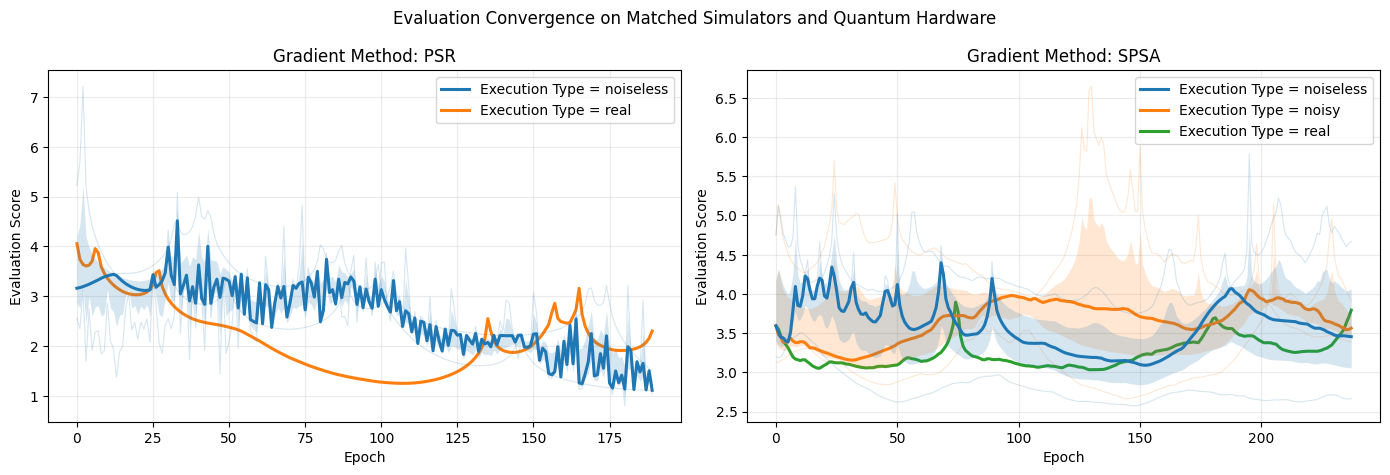

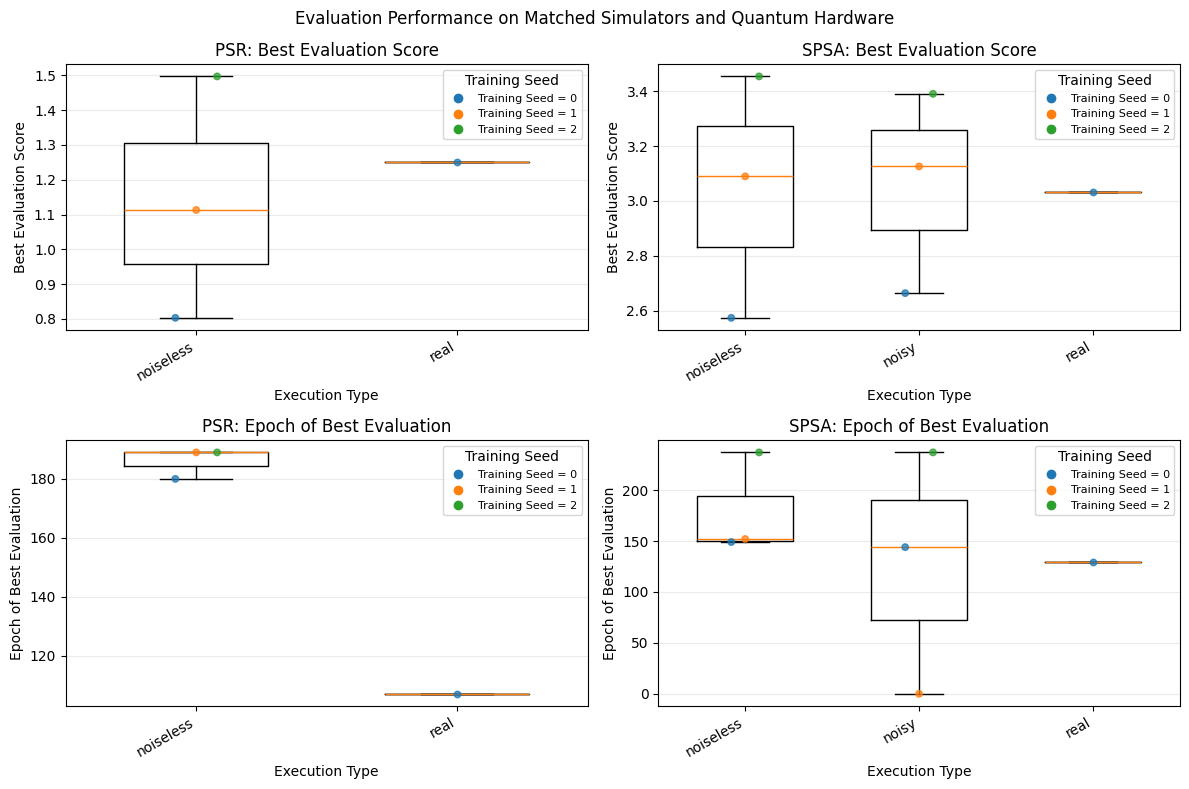

{'run_id': 'base-qml_torch-q4-real-PSR-aerCPU-rand0-seed0', 'gradient_method': 'PSR', 'completed_epochs': 190, 'best_eval': 1.2522631658283698, 'epoch_of_best_eval': 107, 'median_time_per_epoch': 302.93765330314636}
{'run_id': 'base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0', 'gradient_method': 'SPSA', 'completed_epochs': 238, 'best_eval': 3.032940695344694, 'epoch_of_best_eval': 129, 'median_time_per_epoch': 168.67176914215088}


In [15]:
REAL_HARDWARE_FOCUS = {
    "execution_type": "real",
    "implementation": "qml_torch",
    "preset": "base",
    "n_qubits": 4,
    "randomness": 0,
}
hardware_cases = analysis.real_hardware_comparison(
    filters=REAL_HARDWARE_FOCUS,
    eval_method="kl",
)

### 4. Gradient Method Comparison

SPSA, PSR, and REG are compared with preset, execution type, qubits, randomness, and evaluation metric fixed. Timing is absent here because it is analyzed in Section 1.


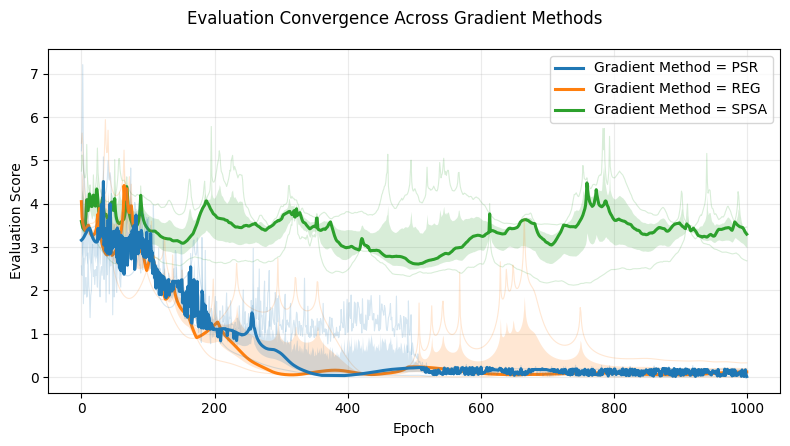

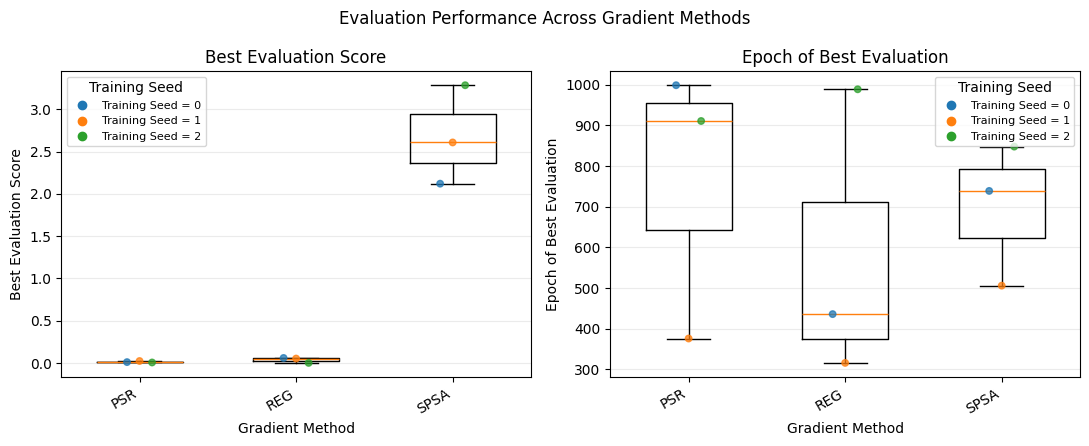

In [16]:
GRADIENT_FOCUS = {
    "preset": "base",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "n_qubits": 4,
    "randomness": 0,
    "eval_method": "kl",
}
gradient_runs = analysis.gradient_comparison(filters=GRADIENT_FOCUS)

### 5. Randomness Effect

Randomness is first studied as a complete five-level sweep, followed by fresh output generation from a selected run and then a wider matched `rand0`/`rand1` comparison.


#### 5.1 Complete five-level randomness sweep

All three presets have complete sweeps containing all five values (`0`, `0.1`, `0.25`, `0.5`, `1`) for seeds 0–2. Select `base`, `ang`, or `amp` with `RANDOMNESS_PRESET` below. Evaluation step volatility is the median absolute change between consecutive evaluation scores; larger values indicate a more erratic learning trajectory.


complete five-level × three-seed sweeps: 6
selected sweep: {'preset': 'base', 'gradient_method': 'PSR', 'n_qubits': 4, 'execution_type': 'noiseless', 'eval_method': 'kl'}


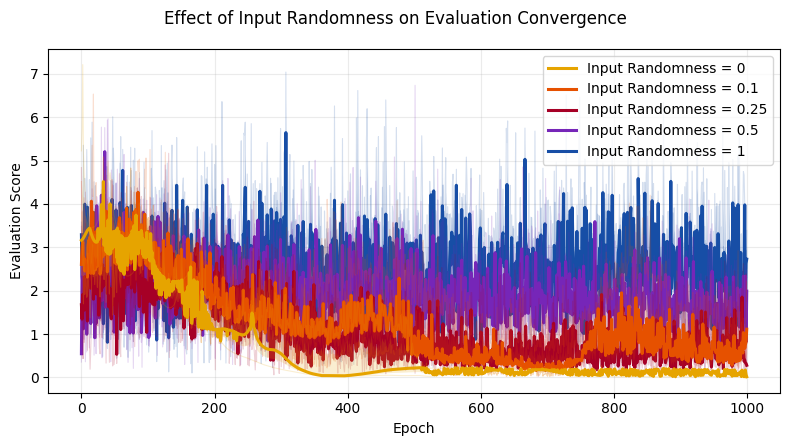

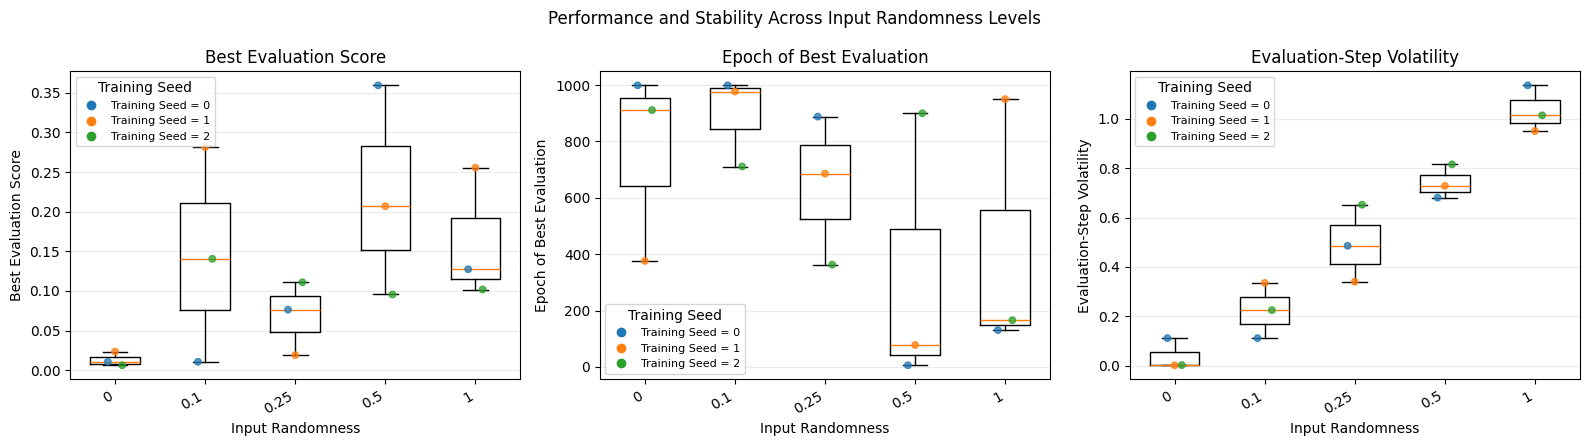

In [17]:
RANDOMNESS_LEVELS = (0, 0.1, 0.25, 0.5, 1)
RANDOMNESS_SEEDS = (0, 1, 2)
RANDOMNESS_PRESET = "base"
RANDOMNESS_SWEEP_INDEX = 0

randomness_main = analysis.randomness_sweep(
    filters={"preset": RANDOMNESS_PRESET},
    levels=RANDOMNESS_LEVELS,
    required_seeds=RANDOMNESS_SEEDS,
    sweep_index=RANDOMNESS_SWEEP_INDEX,
)

#### 5.2 Generate new samples from a selected run

Choose a preset, randomness level, training seed, and number of outputs below. The selected completed noiseless `q4` PSR run is evaluated with its best generator parameters, and every generated output is shown beside the target in one figure. `RANDOMNESS_OUTPUT_INPUT_SEED = None` draws a new random input for every output; set it to an integer for reproducible consecutive input seeds. For `rand0`, the randomizer circuit is disabled, so multiple outputs are identical because no random vector is applied.


{'preset': 'amp', 'gradient_method': 'PSR', 'n_qubits': 4, 'randomness': 0.25, 'training_seed': 0, 'random_input_applied': True, 'run_id': 'amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0.25-seed0', 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0.25-seed0/config.yaml', 'execution_type': 'noiseless', 'parameter_set': 'best', 'random_seed': None, 'input_seeds': (None, None, None, None), 'num_outputs': 4, 'evaluation_score': -0.0, 'evaluation_epoch': 923}


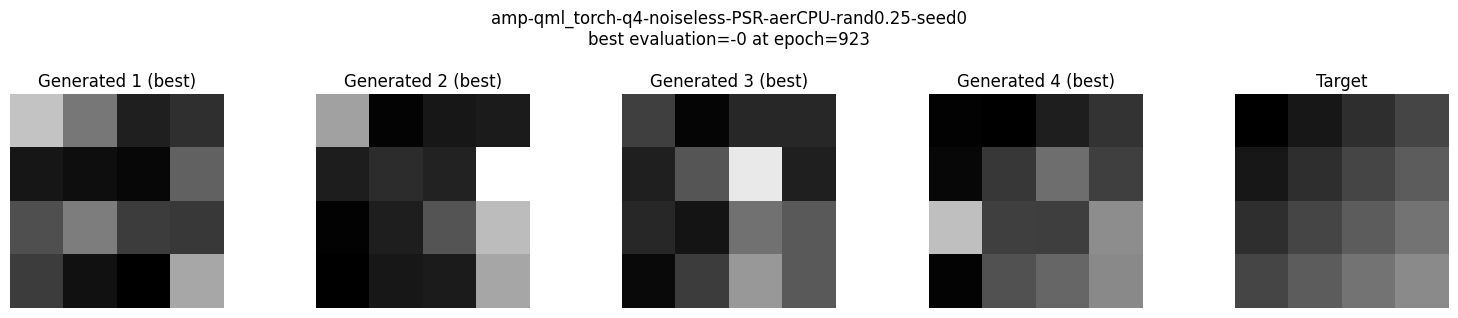

In [18]:
RANDOMNESS_OUTPUT_PRESET = "amp"
RANDOMNESS_OUTPUT_LEVEL = 0.25
RANDOMNESS_OUTPUT_TRAINING_SEED = 0
RANDOMNESS_OUTPUT_INPUT_SEED = None
RANDOMNESS_OUTPUT_COUNT = 4

RANDOMNESS_OUTPUT_FOCUS = {
    "preset": RANDOMNESS_OUTPUT_PRESET,
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "PSR",
    "n_qubits": 4,
    "randomness": RANDOMNESS_OUTPUT_LEVEL,
    "seed": RANDOMNESS_OUTPUT_TRAINING_SEED,
}
randomness_output_manifest = analysis.render_randomness_output(
    filters=RANDOMNESS_OUTPUT_FOCUS,
    random_seed=RANDOMNESS_OUTPUT_INPUT_SEED,
    output_count=RANDOMNESS_OUTPUT_COUNT,
)

#### 5.3 Wider paired rand0/rand1 evidence

The wider dataset is reduced to matched `rand0` and `rand1` pairs. Panels show the change in best evaluation, best epoch, and evaluation step volatility. Zero means no effect; positive score or volatility deltas mean worse or bumpier behavior.


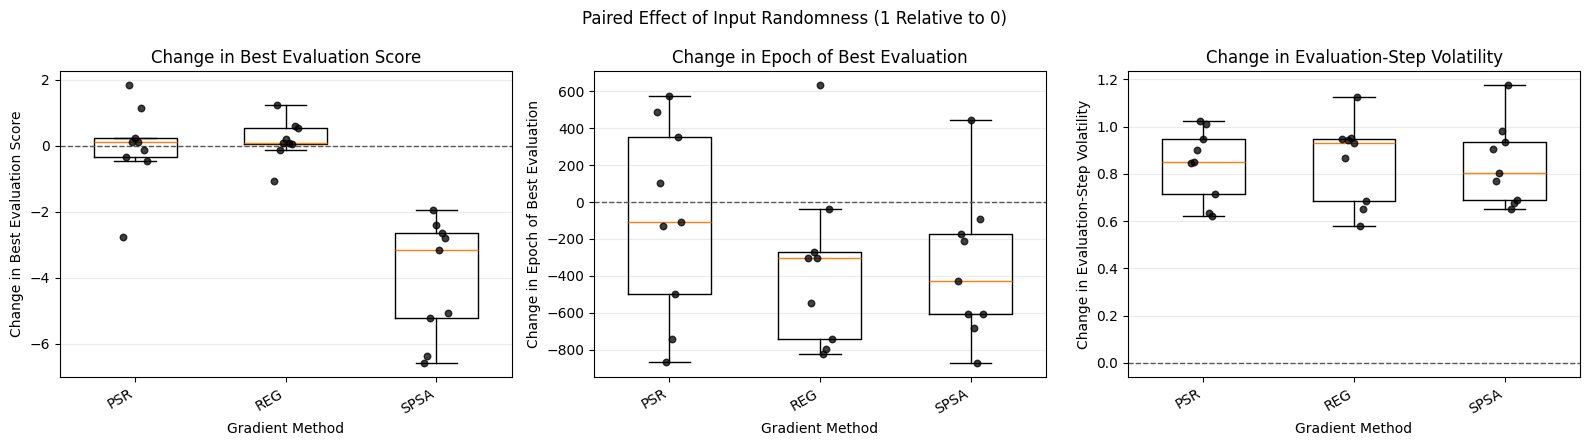

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Change in Best Evaluation Score'}, xlabel='Gradient Method', ylabel='Change in Best Evaluation Score'>,
        <Axes: title={'center': 'Change in Epoch of Best Evaluation'}, xlabel='Gradient Method', ylabel='Change in Epoch of Best Evaluation'>,
        <Axes: title={'center': 'Change in Evaluation-Step Volatility'}, xlabel='Gradient Method', ylabel='Change in Evaluation-Step Volatility'>],
       dtype=object))

In [19]:
RANDOMNESS_PAIR_FOCUS = {
    "preset": "base",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "eval_method": "kl",
}
analysis.randomness_pairs(
    filters=RANDOMNESS_PAIR_FOCUS,
    baseline=0,
    treatment=1,
)

### 6. Scaling Analysis

Scaling is split into preset, execution type, gradient method, and randomness. Each subsection contains representative evaluation dynamics plus best-evaluation and best-epoch scaling across qubit counts. Parameter-count and circuit-width figures are intentionally reserved for the experimental-setup chapter.


#### 6.1 Scaling by preset

Noiseless SPSA and `rand0` are fixed. Each preset is faceted to respect its evaluation metric; qubit count is the compared curve within each facet.


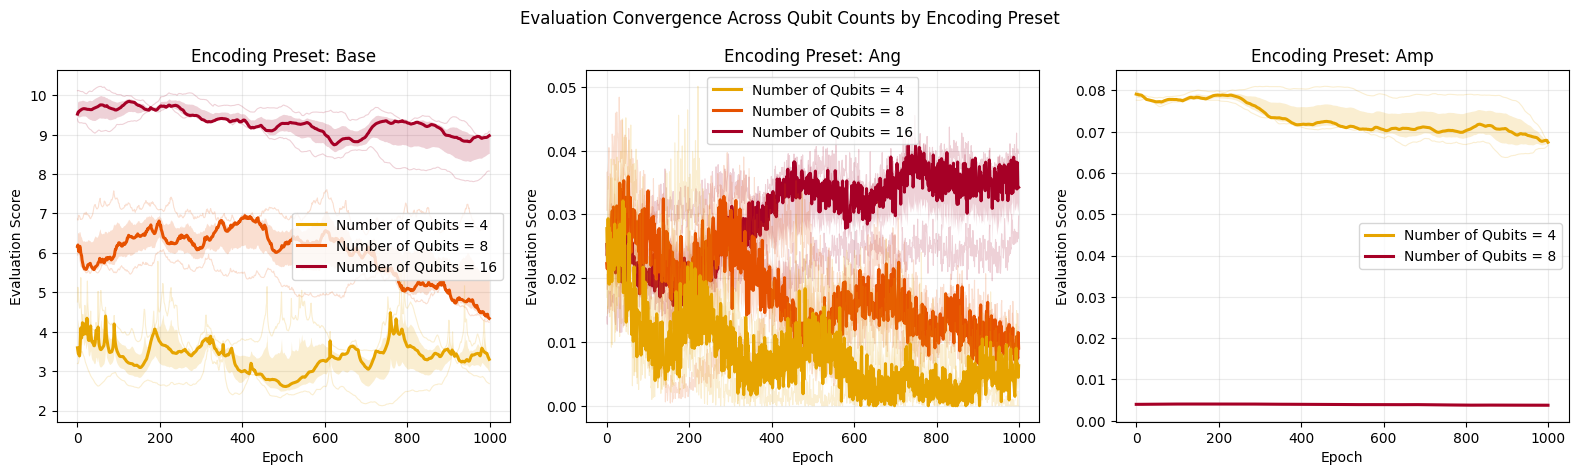

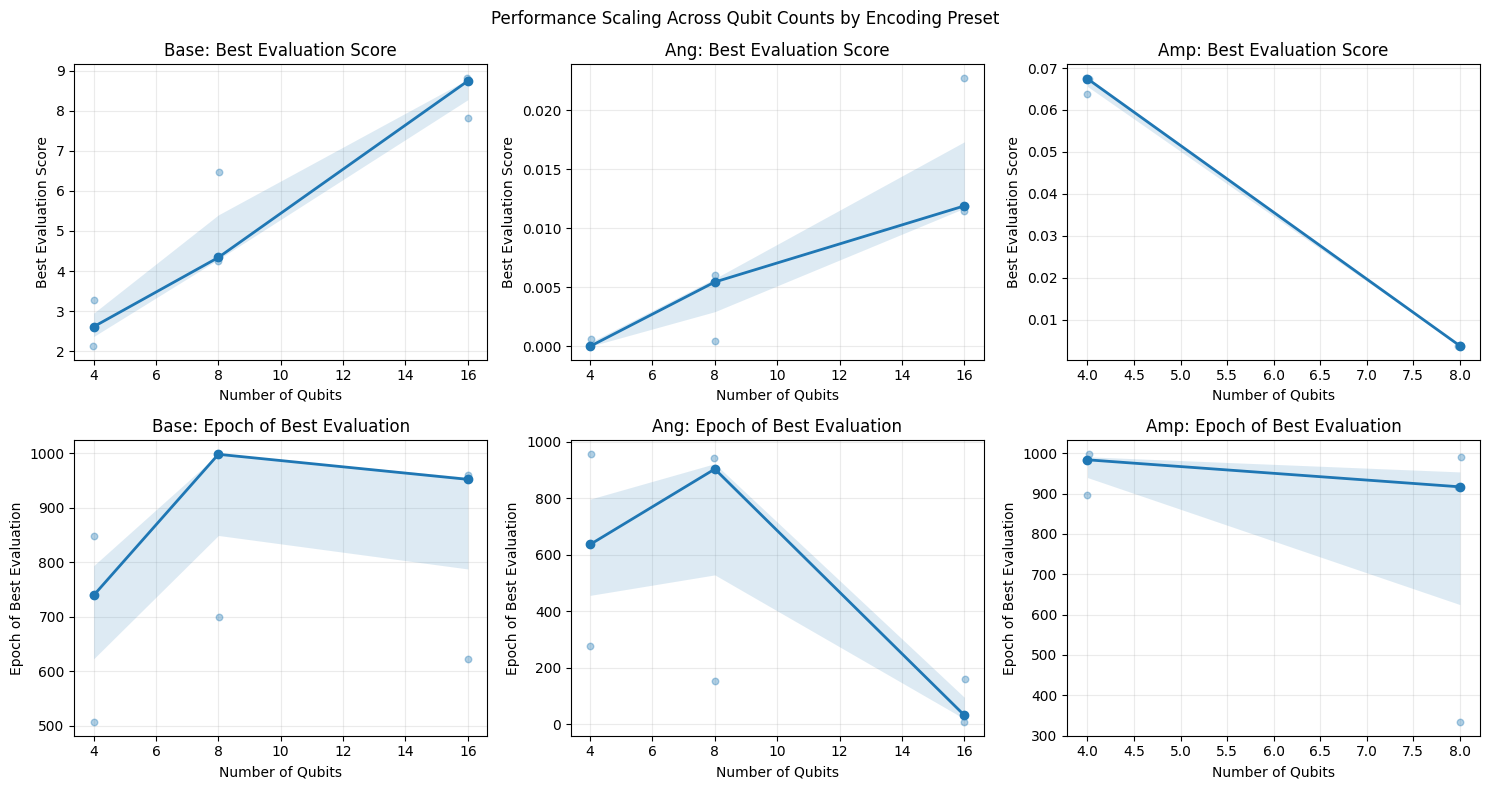

In [20]:
PRESET_SCALING_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "SPSA",
    "randomness": 0,
}
preset_scaling_runs = analysis.preset_scaling(
    filters=PRESET_SCALING_FOCUS,
    presets=PRESET_ORDER,
    qubits_by_preset={"amp": (4, 8)},
)

#### 6.2 Scaling by execution type

The dynamics are split into noiseless and noisy panels for `ang`, SPSA, and `rand0`. Within each panel, curves compare the available qubit counts. No noisy `q16` result is inferred.


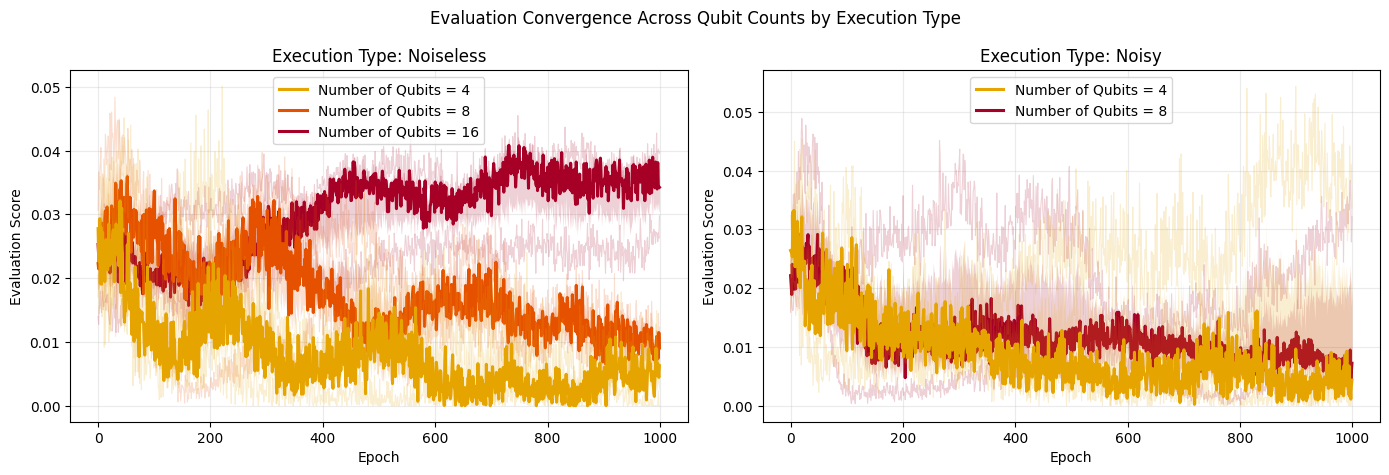

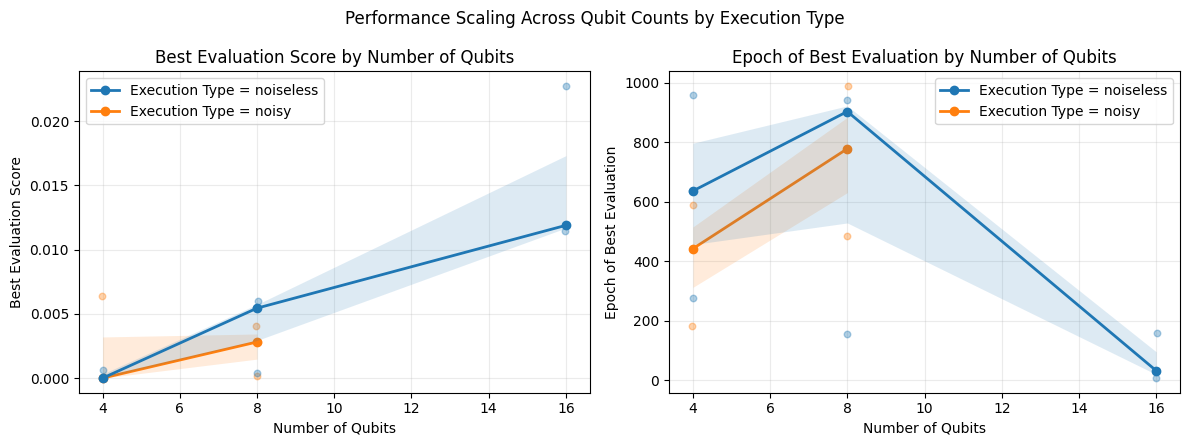

In [21]:
EXECUTION_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "gradient_method": "SPSA",
    "randomness": 0,
}
EXECUTION_TYPES = ("noiseless", "noisy")
execution_scaling_runs = analysis.execution_scaling(
    filters=EXECUTION_SCALING_FOCUS,
    execution_types=EXECUTION_TYPES,
)

#### 6.3 Scaling by gradient method

The dynamics are split into PSR, REG, and SPSA panels for `ang`, noiseless execution, and `rand0`. Within each panel, curves compare the available qubit counts.


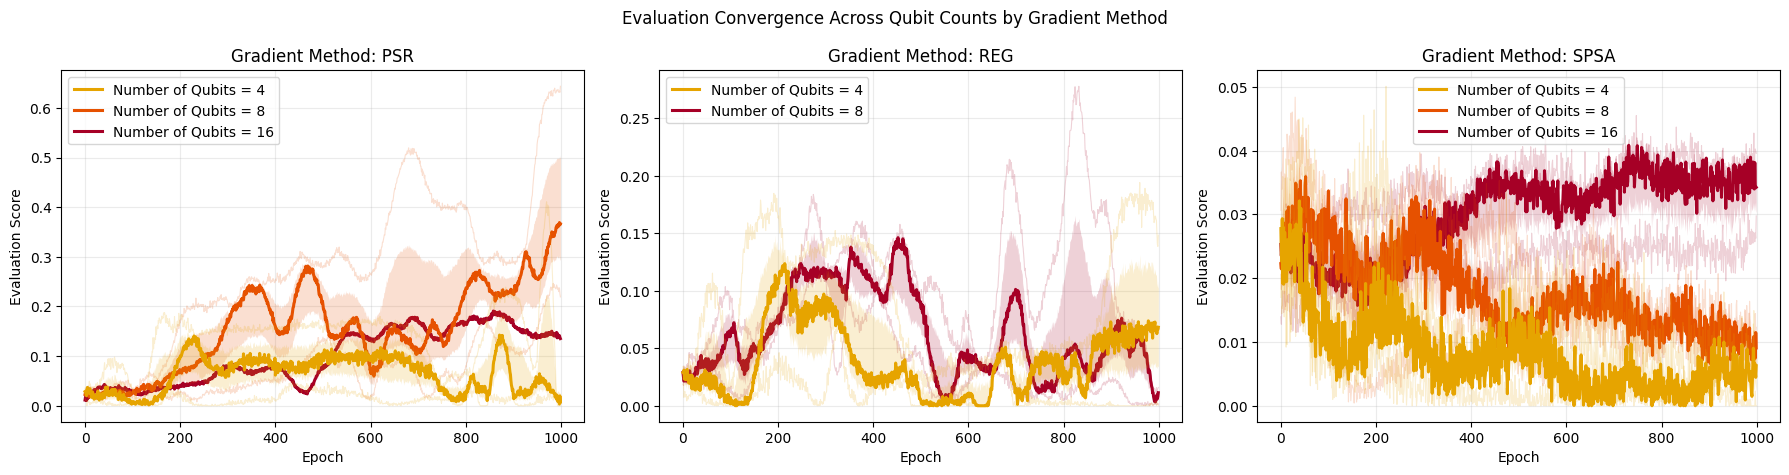

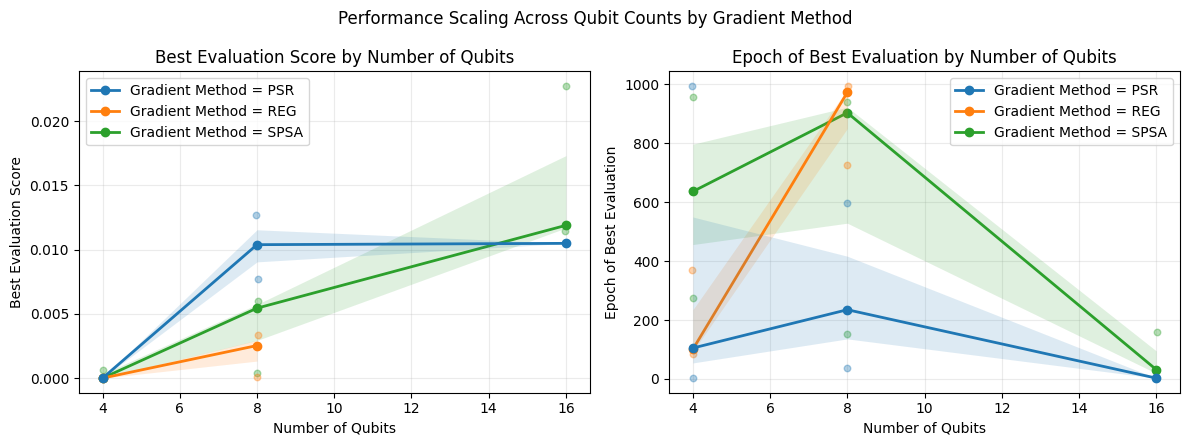

In [22]:
GRADIENT_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "randomness": 0,
}
gradient_scaling_runs = analysis.gradient_scaling(
    filters=GRADIENT_SCALING_FOCUS,
    gradient_methods=GRADIENT_ORDER,
)

#### 6.4 Scaling by randomness

The dynamics are split into `rand0` and `rand1` panels for `ang`, noiseless SPSA. Within each panel, curves compare the available qubit counts.


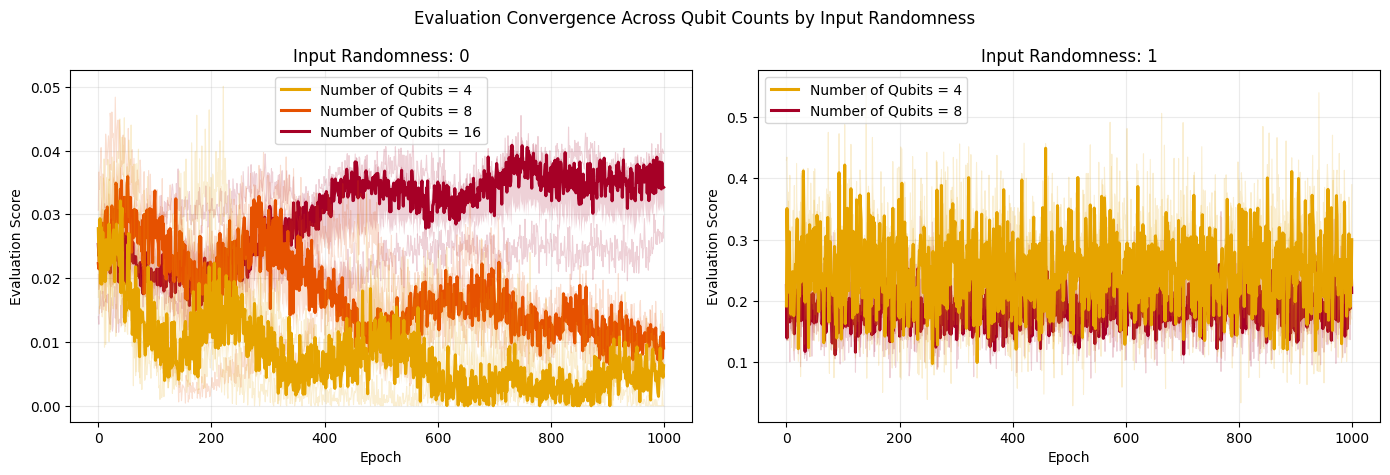

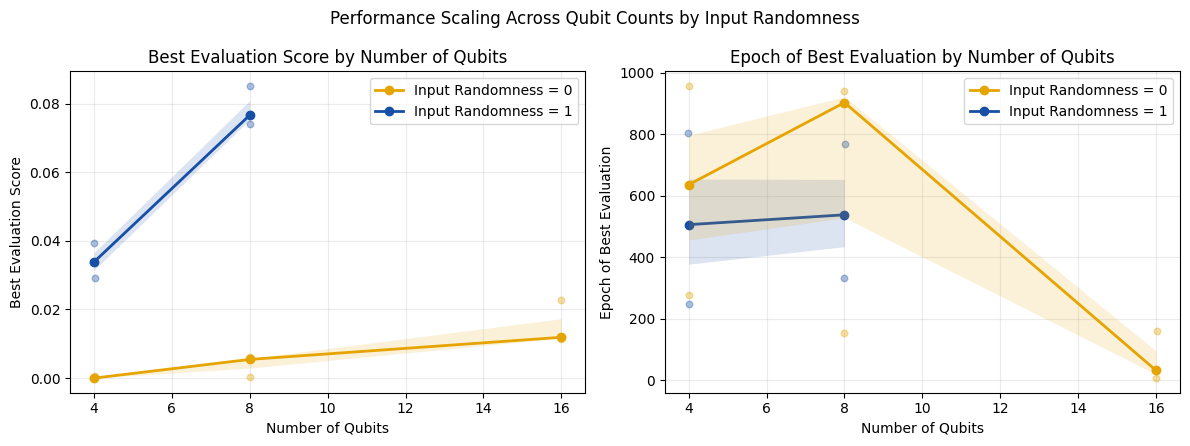

In [23]:
RANDOMNESS_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "SPSA",
}
RANDOMNESS_SCALING_LEVELS = (0, 1)
randomness_scaling_runs = analysis.randomness_scaling(
    filters=RANDOMNESS_SCALING_FOCUS,
    randomness_levels=RANDOMNESS_SCALING_LEVELS,
)

### 7. Implementation and Packing Validation

This final section only demonstrates that each implementation path trains. Fake-real `q4`, SPSA, `rand0`, seed-0 traces cover `qml_torch`, `runtime_packed/separate`, and valid `runtime_packed/joined` cases. No deep quality, timing, or statistical claim is made from one seed.


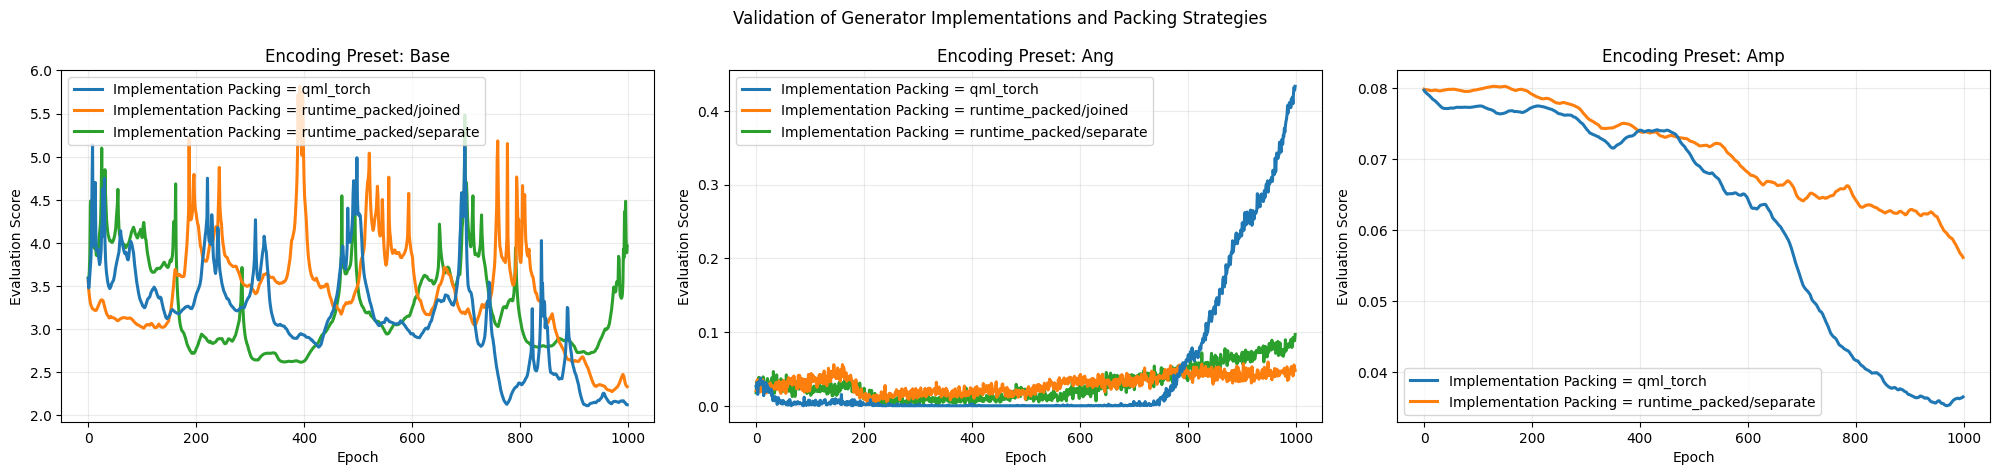

{'run_id': 'amp-qml_torch-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'amp', 'implementation_packing': 'qml_torch', 'completed_epochs': 1000, 'best_eval': 0.03519801034232682, 'epoch_of_best_eval': 969}
{'run_id': 'amp-runtime_packed-separate-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'amp', 'implementation_packing': 'runtime_packed/separate', 'completed_epochs': 1000, 'best_eval': 0.05607925661721558, 'epoch_of_best_eval': 999}
{'run_id': 'ang-qml_torch-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'ang', 'implementation_packing': 'qml_torch', 'completed_epochs': 1000, 'best_eval': -0.0, 'epoch_of_best_eval': 65}
{'run_id': 'ang-runtime_packed-joined-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'ang', 'implementation_packing': 'runtime_packed/joined', 'completed_epochs': 1000, 'best_eval': 0.002163238823413849, 'epoch_of_best_eval': 206}
{'run_id': 'ang-runtime_packed-separate-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'ang', 'implementation_packing': 'runtime_

In [24]:
VALIDATION_FOCUS = {
    "execution_type": "fake_real",
    "n_qubits": 4,
    "gradient_method": "SPSA",
    "randomness": 0,
    "seed": 0,
}
fake_validation = analysis.implementation_validation(
    filters=VALIDATION_FOCUS,
    presets=PRESET_ORDER,
)